# Spanish solar, Part A: how far does a cloud reach?

Spread solar farms across Spain and a cloud over one should not darken the others - in
summer. In winter a single high-pressure system can sit over the whole peninsula for
days, and every farm goes dim together. **How far weather "reaches" sets how much
diversification a solar fleet really has.**

This notebook measures it, from an ML-ready weather dataset built with ECMWF's
`anemoi-datasets` (see `iberia_datasets/`): 25 sites, hourly, one year.

> **Data.** ERA5 reanalysis for 2023, hourly, 0.25°, built into an Anemoi dataset that
> passes every quality check in `iberia_datasets/`. (The same notebook was first run on a
> synthetic placeholder with a correlation length planted on purpose; it recovered the
> planted value month by month - the check that the method is sound. If the dataset is
> ever a placeholder again, the figures are stamped and section 4 shows that check.)

In [1]:
import sys, datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import figstyle
figstyle.apply()
import solar_sites as ss
from iberia import synthetic as syn
from corrlib import Correlator
from corrlib import correlation_measures as cm

D = ss.load()
SYNTHETIC = D['is_synthetic']
def stamp(fig):
    if SYNTHETIC:
        figstyle.watermark(fig)

D['anom_sites'] = ss.deseasonalise(D['k_sites'], D['times'])
D['anom_grid'] = ss.deseasonalise(D['k_grid'], D['times'])
print(f"{len(D['names'])} sites, {D['k_sites'].shape[1]} hours; synthetic placeholder: {SYNTHETIC}")

C:\Users\kevin\OneDrive\Documents\Portfolio_Dev_claude\008-spanish-solar-portfolio\solar_sites.py:110: RuntimeWarning: All-NaN slice encountered
  typical = np.nanmedian(block, axis=1, keepdims=True)


25 sites, 8760 hours; synthetic placeholder: False


## The clear-sky index

Raw solar output at any two Spanish sites correlates at about 0.95 - because the sun
rises and sets at both. That number says nothing. Dividing each hour's irradiance by what
a cloudless sky would give, the **clear-sky index** `k`, removes the sun and leaves the
weather: 1 is clear, small is overcast. Night and low-sun hours are dropped.

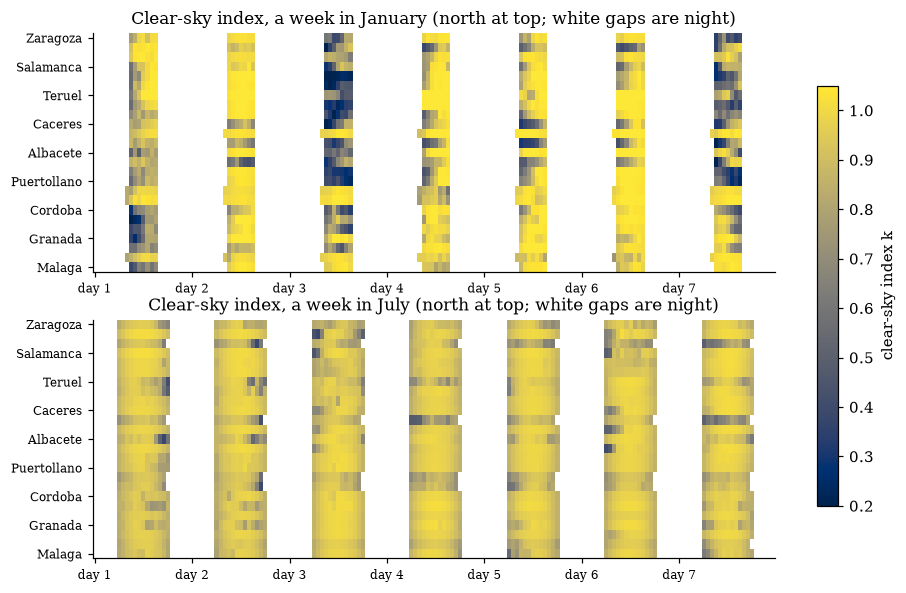

In [2]:
#a winter week and a summer week, every site
def week(start):
    t = np.asarray(D['times'], dtype='datetime64[h]')
    return (t >= np.datetime64(start)) & (t < np.datetime64(start) + np.timedelta64(7 * 24, 'h'))

order = np.argsort(D['lat'])[::-1]                      # north at the top
fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=False)
for ax, (label, start) in zip(axes, [('a week in January', '2023-01-09'), ('a week in July', '2023-07-10')]):
    w = week(start)
    k = D['k_sites'][order][:, w]
    im = ax.imshow(k, aspect='auto', cmap='cividis', vmin=0.2, vmax=1.05, interpolation='nearest')
    ax.set_yticks(range(len(order))[::3])
    ax.set_yticklabels([D['names'][i] for i in order][::3], fontsize=8)
    days = np.arange(0, w.sum(), 24)
    ax.set_xticks(days)
    ax.set_xticklabels([f"day {i + 1}" for i in range(len(days))], fontsize=8)
    ax.set_title(f"Clear-sky index, {label} (north at top; white gaps are night)")
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label='clear-sky index k')
stamp(fig)
figstyle.save(fig, 'figures/fig1_two_weeks')
plt.show()

## The sun creeps back in

Dividing by a clear-sky model should leave only the weather. On real data it does not
quite: averaged over all 25 sites, the clear-sky index still rises through the morning
and falls through the afternoon - a daily shape every site shares, which would
masquerade as weather that reaches everywhere. (On the synthetic placeholder it was
invisible, because the placeholder was generated with the same clear-sky model.) So
each site's typical value for that hour of that month is subtracted, and only what is
left - the weather - is correlated.

C:\Users\kevin\AppData\Local\Temp\ipykernel_332\2015145805.py:5: RuntimeWarning: All-NaN slice encountered
  med = pd.Series(np.nanmedian(D['k_sites'][:, sel], axis=0), index=t.hour[sel]).groupby(level=0).median()
C:\Users\kevin\AppData\Local\Temp\ipykernel_332\2015145805.py:5: RuntimeWarning: All-NaN slice encountered
  med = pd.Series(np.nanmedian(D['k_sites'][:, sel], axis=0), index=t.hour[sel]).groupby(level=0).median()


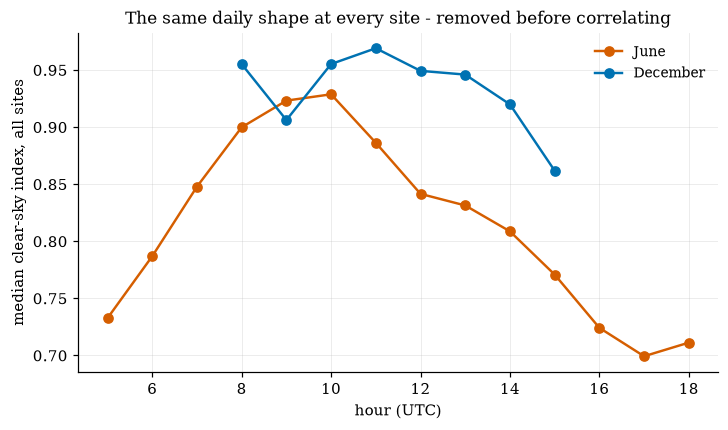

In [3]:
t = pd.to_datetime(D['times'])
fig, ax = plt.subplots(figsize=(7.5, 4))
for month, label, colour in [(6, 'June', figstyle.PALETTE[1]), (12, 'December', figstyle.PALETTE[0])]:
    sel = np.asarray(t.month == month)
    med = pd.Series(np.nanmedian(D['k_sites'][:, sel], axis=0), index=t.hour[sel]).groupby(level=0).median()
    ax.plot(med.index, med.values, 'o-', color=colour, label=label)
ax.set_xlabel('hour (UTC)'); ax.set_ylabel('median clear-sky index, all sites')
ax.set_title('The same daily shape at every site - removed before correlating')
ax.legend()
stamp(fig)
figstyle.save(fig, 'figures/fig0_daily_shape')
plt.show()

## Correlation against distance, by season

For every pair of sites, the Gaussian-rank correlation of `k` (rank, map to normal scores,
then Pearson - the right tool for a bounded, skewed variable), against the distance
between them. The fitted curve is $\rho(d) = e^{-(d/L)^p}$: $L$ is the **correlation
length**, and $p$ lets the data choose its own shape.

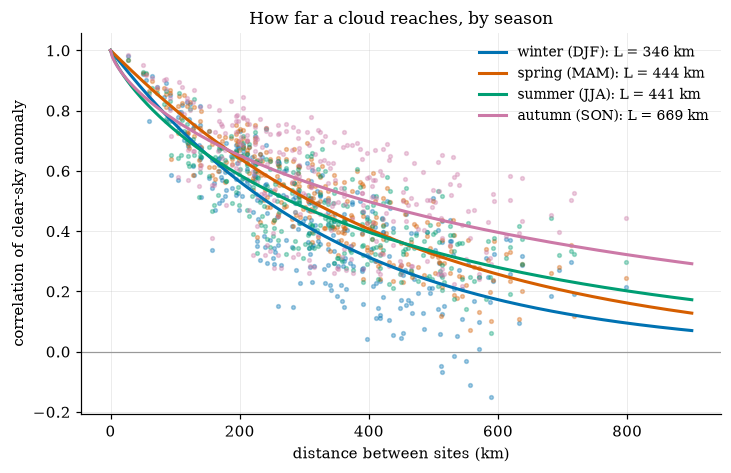

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
fits = {}
dgrid = np.linspace(0, 900, 300)
for (name, months), colour in zip(ss.SEASONS.items(), figstyle.PALETTE):
    m = ss.season_mask(D['times'], months)
    C, X = ss.correlation(D['anom_sites'][:, m])
    L, p, se, d, r = ss.fit_correlation_length(C, D['lat'], D['lon'])
    fits[name] = dict(L=L, p=p, se=se, C=C, X=X)
    ax.scatter(d, r, s=6, color=colour, alpha=0.35)
    ax.plot(dgrid, ss.stretched_exponential(dgrid, L, p), color=colour, lw=2,
            label=f"{name}: L = {L:.0f} km")
ax.axhline(0, color='0.6', lw=0.8)
ax.set_xlabel('distance between sites (km)')
ax.set_ylabel('correlation of clear-sky anomaly')
ax.set_title('How far a cloud reaches, by season')
ax.legend()
stamp(fig)
figstyle.save(fig, 'figures/fig2_correlation_vs_distance')
plt.show()

## The reach of the weather, month by month

The same fit, one month at a time. On synthetic data this is where the method is checked
against a planted value; on ERA5 it is the seasonal cycle of how far Spanish weather
reaches.

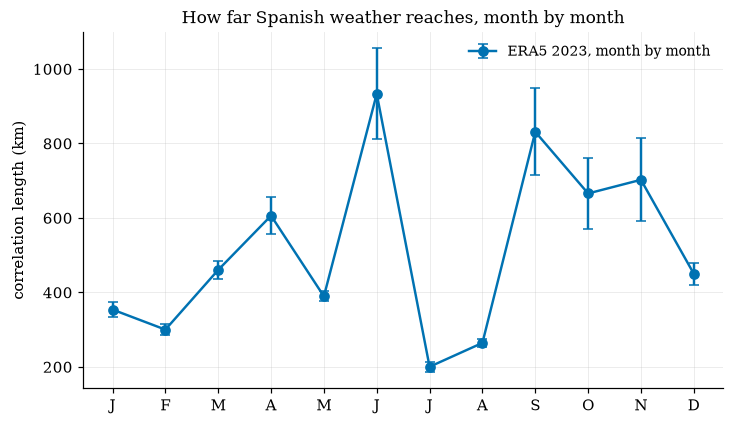

J: L =  353.8 km   shape p = 0.98
F: L =  300.0 km   shape p = 1.02
M: L =  460.4 km   shape p = 1.03
A: L =  606.0 km   shape p = 0.84
M: L =  389.4 km   shape p = 1.05
J: L =  933.2 km   shape p = 0.65
J: L =  200.3 km   shape p = 1.17
A: L =  264.4 km   shape p = 1.21
S: L =  831.2 km   shape p = 0.62
O: L =  665.7 km   shape p = 0.73
N: L =  702.4 km   shape p = 0.62
D: L =  450.2 km   shape p = 0.91


In [5]:
months = range(1, 13)
recovered, lo, hi, shape = [], [], [], []
for mo in months:
    m = ss.season_mask(D['times'], (mo,))
    C, X = ss.correlation(D['anom_sites'][:, m])
    L, p, se, *_ = ss.fit_correlation_length(C, D['lat'], D['lon'])
    recovered.append(L); lo.append(L - 2 * se[0]); hi.append(L + 2 * se[0]); shape.append(p)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
if SYNTHETIC:
    #planted field has correlation exp(-2 d^2 / L^2): e-folding distance L / sqrt(2)
    days = np.arange(1, 366)
    planted = [syn.planted_length_km(dt.datetime(2023, 1, 1) + dt.timedelta(days=int(d) - 1)) / np.sqrt(2) for d in days]
    ax.plot(days / 30.44 + 0.5, planted, 'k--', lw=1.2, label='planted')
ax.errorbar(np.array(months), recovered, yerr=[np.subtract(recovered, lo), np.subtract(hi, recovered)],
            fmt='o-', color=figstyle.PALETTE[0], capsize=3,
            label='recovered, month by month' if SYNTHETIC else 'ERA5 2023, month by month')
ax.set_xticks(months)
ax.set_xticklabels(list('JFMAMJJASOND'))
ax.set_ylabel('correlation length (km)')
ax.set_title('Method check: recovering a known correlation length' if SYNTHETIC
             else 'How far Spanish weather reaches, month by month')
ax.legend()
stamp(fig)
figstyle.save(fig, 'figures/fig3_method_check' if SYNTHETIC else 'figures/fig3_monthly_reach')
plt.show()

for mo, L, p in zip(months, recovered, shape):
    print(f"{'JFMAMJJASOND'[mo - 1]}: L = {L:6.1f} km   shape p = {p:.2f}")
if SYNTHETIC:
    err = np.array(recovered) - np.array([syn.planted_length_km(dt.datetime(2023, mo, 15)) / np.sqrt(2) for mo in months])
    print(f"recovered minus planted: median {np.median(err):+.0f} km, worst {err[np.argmax(np.abs(err))]:+.0f} km")

## How many independent sites?

$N_\mathrm{eff} = (\sum\lambda)^2 / \sum \lambda^2$, from the eigenvalues of the correlation
matrix: 25 if every site were independent, 1 if they all moved as one. Hourly data is
strongly autocorrelated, so the number of *independent* hours is far smaller than the
number of hours - the `Correlator` corrects for that (Bartlett), and cleans the matrix
with random-matrix shrinkage before counting.

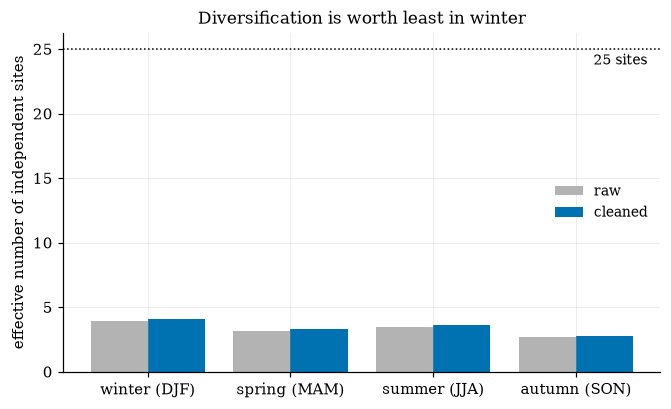

winter (DJF)    626 daylight hours ~    113 independent;  N_eff raw   3.9, cleaned   4.1
spring (MAM)    986 daylight hours ~     96 independent;  N_eff raw   3.1, cleaned   3.3
summer (JJA)   1074 daylight hours ~    123 independent;  N_eff raw   3.5, cleaned   3.6
autumn (SON)    792 daylight hours ~     74 independent;  N_eff raw   2.7, cleaned   2.8


In [6]:
rows = []
for name, months in ss.SEASONS.items():
    m = ss.season_mask(D['times'], months)
    _, X = ss.correlation(D['anom_sites'][:, m])
    c = Correlator(measure='gaussian_rank', clean='nonlinear_shrinkage', effective_n='bartlett')
    c.fit(X, labels=D['names'])
    summary = c.summary()
    rows.append((name, X.shape[1], summary['n_effective'], summary['effective_rank_measured'],
                 summary['effective_rank_final']))

fig, ax = plt.subplots(figsize=(7, 4))
pos = np.arange(len(rows))
ax.bar(pos - 0.2, [r[3] for r in rows], 0.4, color='0.7', label='raw')
ax.bar(pos + 0.2, [r[4] for r in rows], 0.4, color=figstyle.PALETTE[0], label='cleaned')
ax.axhline(len(D['names']), color='k', ls=':', lw=1)
ax.text(len(rows) - 0.5, len(D['names']) - 1.2, f"{len(D['names'])} sites", ha='right', fontsize=9)
ax.set_xticks(pos)
ax.set_xticklabels([r[0] for r in rows])
ax.set_ylabel('effective number of independent sites')
ax.set_title('Diversification is worth least in winter')
ax.legend()
stamp(fig)
figstyle.save(fig, 'figures/fig4_effective_sites')
plt.show()
for name, hours, n_eff_obs, raw, clean in rows:
    print(f"{name:13s} {hours:5d} daylight hours ~ {n_eff_obs:6.0f} independent;  N_eff raw {raw:5.1f}, cleaned {clean:5.1f}")

## The map

Correlation of every grid point with Seville, winter against summer. The bullseye is the
reach of the weather.

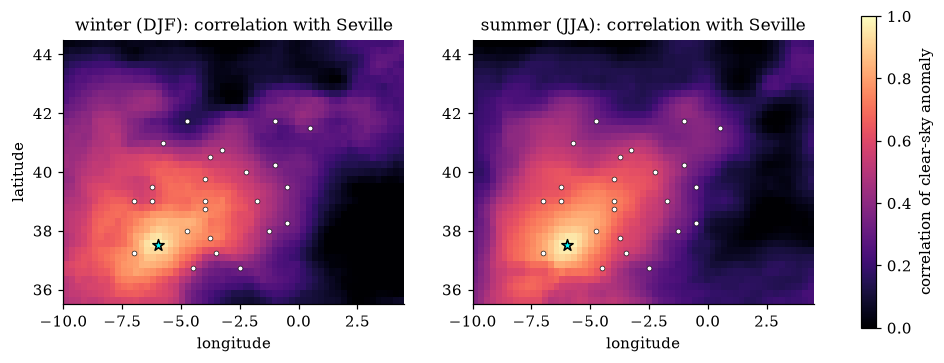

In [7]:
def correlation_map(months, site='Sevilla'):
    m = ss.season_mask(D['times'], months)
    k = D['anom_grid'][:, m]
    s_idx = D['names'].index(site)
    ref = D['anom_sites'][s_idx, m]
    ok = np.isfinite(ref) & np.all(np.isfinite(k), axis=0)
    Z = cm.gaussian_scores(k[:, ok])
    z = cm.gaussian_scores(ref[ok][None, :])[0]
    Z = (Z - Z.mean(1, keepdims=True)) / Z.std(1, keepdims=True)
    z = (z - z.mean()) / z.std()
    return Z @ z / len(z)

lats, lons = D['grid_lat'], D['grid_lon']
ulat, ulon = np.unique(lats)[::-1], np.unique(lons)
extent = [ulon.min(), ulon.max(), ulat.min(), ulat.max()]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (label, months) in zip(axes, [('winter (DJF)', (12, 1, 2)), ('summer (JJA)', (6, 7, 8))]):
    r = correlation_map(months).reshape(len(ulat), len(ulon))
    im = ax.imshow(r, extent=extent, cmap='magma', vmin=0, vmax=1, origin='upper', aspect=1.25)
    ax.scatter(D['lon'], D['lat'], s=10, color='white', edgecolor='k', linewidth=0.4)
    s_idx = D['names'].index('Sevilla')
    ax.scatter(D['lon'][s_idx], D['lat'][s_idx], s=60, marker='*', color='cyan', edgecolor='k')
    ax.set_title(f"{label}: correlation with Seville")
    ax.set_xlabel('longitude')
    ax.grid(False)
axes[0].set_ylabel('latitude')
fig.colorbar(im, ax=axes, shrink=0.8, label='correlation of clear-sky anomaly')
stamp(fig)
figstyle.save(fig, 'figures/hero')
plt.show()

**On ERA5 for 2023, Spanish weather reaches far.** The correlation of clear-sky
anomalies falls to 1/e over **about 350 km in winter, 440 km in spring and summer, and
670 km in autumn** (±15-90 km). Twenty-five sites spread across 1,000 km of Spain
diversify like only **three or four independent ones** (N_eff 2.7-3.9) - autumn, when
large Atlantic systems sweep the whole peninsula, worst of all.

The expected seasonal story - short summer correlations from local convective cloud -
is *not* what the data show. Summer's length is no shorter than spring's; what changes
is the shape (p ≈ 0.8 vs 1.0): correlation drops faster over the first 100 km, then
lingers. Month by month the length wanders between 200 and 930 km - with only ~30
independent hours of weather per month, single months are noisy, and the seasonal fits
are the ones to trust.

Two honest caveats. ERA5's 31 km grid smooths small clouds, which can only *lengthen*
correlations - so these are upper bounds. And the first pass on real data found
correlations near 1 everywhere: the shared daily shape above, not weather. Removing it
is what makes these numbers mean anything.

Next: the same analysis on CERRA (5.5 km) to ask whether dataset resolution changes the
answer; then prices, cannibalisation and the portfolio.